# **Sesión práctica 2: Análisis Univariado, bivariado y multivariado**
**Autores:** Camilo Mosquera y José Miguel Correa  
**Fecha:** 09 de marzo de 2026

## **Parte 1: Análisis Univariado**

In [2]:
# Librerías
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis, norm, pearsonr, spearmanr

# 1) Instala kagglehub (existe la posibilidad de que no se necesite, sin embargo lo dejamos para evitar errores)

!pip -q install kagglehub[pandas-datasets]

import kagglehub

# 2) Descarga el dataset (Kaggle handle)
dataset_handle = "saketsingh9728/movies-dataset"
dataset_path = kagglehub.dataset_download(dataset_handle)

print("Dataset descargado desde:", dataset_path)

# 3) Buscamos el archivo CSV dentro del dataset
csv_files = sorted(glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True))
print("CSV encontrado:", os.path.basename(csv_files[0]))

# 4) Cargamos el CSV (es el primero porque es el unico que tenemos)
target = csv_files[0]
df = pd.read_csv(target)

print("Archivo cargado:", os.path.basename(target))

100%|██████████| 1.81M/1.81M [00:00<00:00, 153MB/s]

Extracting files...
Dataset descargado desde: /root/.cache/kagglehub/datasets/saketsingh9728/movies-dataset/versions/1
CSV encontrado: movies_dataset.csv
Archivo cargado: movies_dataset.csv


### **Ejercicio 1: Cálculo de medidas de tendencia central**

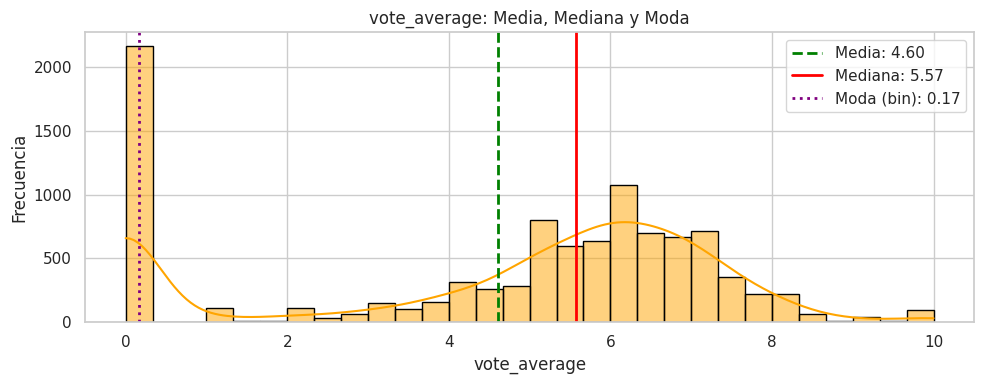

In [ ]:
sns.set_theme(style="whitegrid")

# 1) Datos reales (limpios)
x = df["vote_average"].dropna().to_numpy()

# 2) Media y mediana
media = np.mean(x)
mediana = np.median(x)

# 3) Moda (para continua: estimada por bin del histograma)
counts, bin_edges = np.histogram(x, bins=30)
idx = np.argmax(counts)
moda = (bin_edges[idx] + bin_edges[idx + 1]) / 2

# 4) Gráfica tipo ejemplo
plt.figure(figsize=(10,4))
sns.histplot(x, bins=30, kde=True, color = "orange", edgecolor="black")

plt.axvline(media, linestyle="--", linewidth=2, color = "green", label=f"Media: {media:.2f}")
plt.axvline(mediana, linestyle="-", linewidth=2, color = "red", label=f"Mediana: {mediana:.2f}")
plt.axvline(moda, linestyle=":", linewidth=2,color = "purple", label=f"Moda (bin): {moda:.2f}")

plt.title("vote_average: Media, Mediana y Moda")
plt.xlabel("vote_average")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretaciones:

En este caso, la media es 4.604, lo que indica que en promedio los valores se sitúan cerca de 4.6 unidades, mientras que la mediana es 5.571, lo que significa que el 50 % de los datos está por debajo de este valor y el otro 50 % por encima. La moda, estimada mediante el histograma, es 0.167, lo que sugiere una mayor frecuencia de valores cercanos a ese punto. La diferencia entre media, mediana y moda indica que la distribución no es completamente simétrica y presenta una ligera asimetría hacia la izquierda, influenciada por algunos valores bajos.



### **Ejercicio 2: Cálculo de medidas de dispersión**

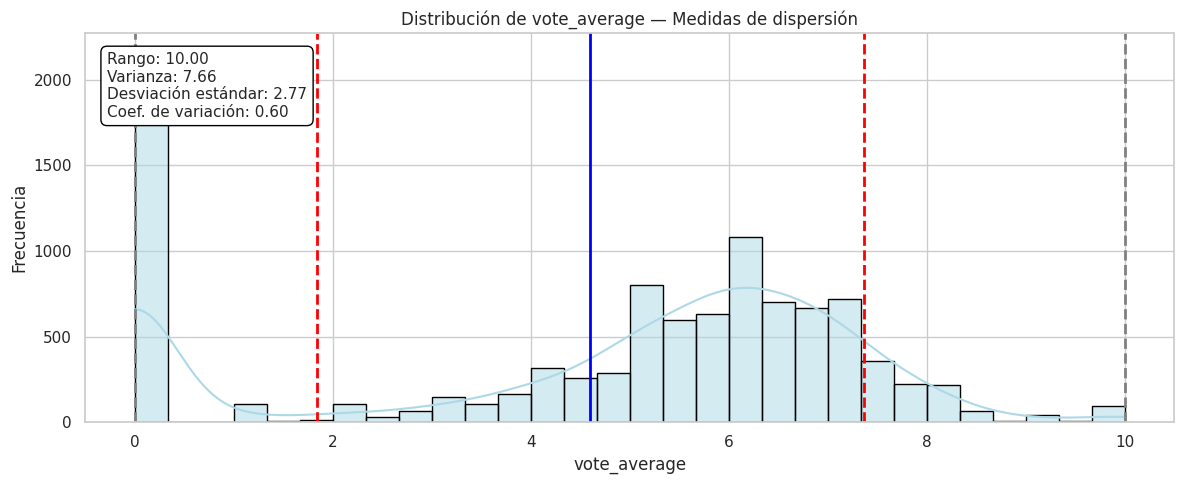

In [ ]:
sns.set_theme(style="whitegrid")

# Datos limpios
x = df["vote_average"].dropna().to_numpy()

# Medidas
media = np.mean(x)
varianza = np.var(x, ddof=1)
desv_std = np.std(x, ddof=1)
rango = np.max(x) - np.min(x)
cv = desv_std / media if media != 0 else np.nan

xmin = np.min(x)
xmax = np.max(x)

# Gráfica
plt.figure(figsize=(12,5))
sns.histplot(x, bins=30, kde=True, color="lightblue", edgecolor="black")

# Media
plt.axvline(media, color="blue", linewidth=2)

# ± 1 desviación estándar
plt.axvline(media - desv_std, color="red", linestyle="--", linewidth=2)
plt.axvline(media + desv_std, color="red", linestyle="--", linewidth=2)

# Rango (mín y máx)
plt.axvline(xmin, color="gray", linestyle="--", linewidth=2)
plt.axvline(xmax, color="gray", linestyle="--", linewidth=2)

plt.title("Distribución de vote_average — Medidas de dispersión")
plt.xlabel("vote_average")
plt.ylabel("Frecuencia")

# Cuadro de estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desv_std:.2f}\n"
    f"Coef. de variación: {cv:.2f}"
)

plt.text(
    0.02, 0.95, texto,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black")
)

plt.tight_layout()
plt.show()

## Interpretaciones:

En este conjunto, la varianza es 7.656 y la desviación estándar es 2.767, lo que indica que, en promedio, los valores se alejan alrededor de 2.77 unidades de la media (4.604). El rango es 10.000, evidenciando una amplitud considerable entre el valor mínimo y el máximo. Además, el coeficiente de variación es 0.601 (60.1 %), lo que señala una variabilidad relativa alta; en conjunto, estas medidas muestran que los datos presentan una dispersión considerable y no se concentran fuertemente alrededor del promedio.



### **Ejercicio 3: Cálculo de medidas de distribución**

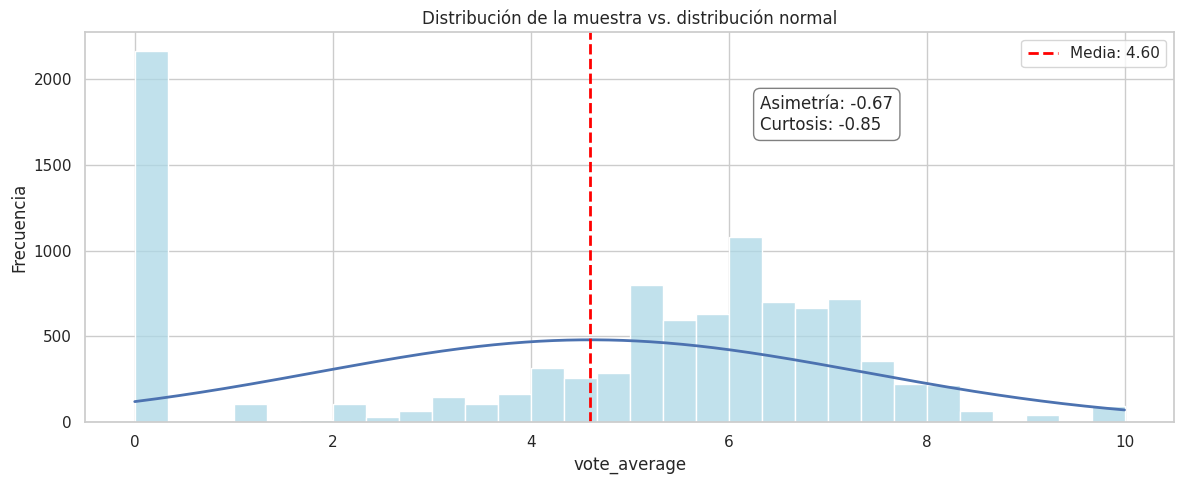

In [ ]:
sns.set_theme(style="whitegrid")

# Muestra (tu data real)
x = df["vote_average"].dropna().to_numpy()

# Parámetros muestrales
mu = np.mean(x)
sigma = np.std(x, ddof=1)

# Asimetría y curtosis (exceso, normal ~ 0)
asim = skew(x, bias=False)
curt = kurtosis(x, fisher=True, bias=False)

# Gráfica: muestra vs normal
plt.figure(figsize=(12,5))
ax = plt.gca()

# Histograma (frecuencia) + KDE opcional (si quieres)
sns.histplot(x, bins=30, color="lightblue", edgecolor="white", ax=ax)

# Curva normal escalada a "frecuencia" (para que se vea como en la imagen)
xx = np.linspace(x.min(), x.max(), 500)
bin_width = (x.max() - x.min()) / 30
normal_y = norm.pdf(xx, loc=mu, scale=sigma) * len(x) * bin_width
ax.plot(xx, normal_y, linewidth=2)

# Línea de la media
ax.axvline(mu, color="red", linestyle="--", linewidth=2, label=f"Media: {mu:.2f}")
ax.legend()

ax.set_title("Distribución de la muestra vs. distribución normal")
ax.set_xlabel("vote_average")
ax.set_ylabel("Frecuencia")

# Cajita con métricas (asimetría y curtosis)
ax.text(
    0.62, 0.75,
    f"Asimetría: {asim:.2f}\nCurtosis: {curt:.2f}",
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray")
)

plt.tight_layout()
plt.show()

## Interpretaciones:

La asimetría (skewness) es −0.672, lo que indica una asimetría negativa o sesgo hacia la izquierda, es decir, una cola más extendida hacia valores pequeños mientras la mayor concentración de datos se ubica en valores más altos. Por otro lado, la curtosis (exceso) es −0.847, lo que señala que la distribución es platicúrtica, es decir, más plana que una distribución normal y con menor concentración alrededor de la media. En conjunto, esto sugiere una distribución ligeramente inclinada hacia valores bajos y relativamente más extendida.



### **Ejercicio 4: Cálculo de medidas de percentiles**

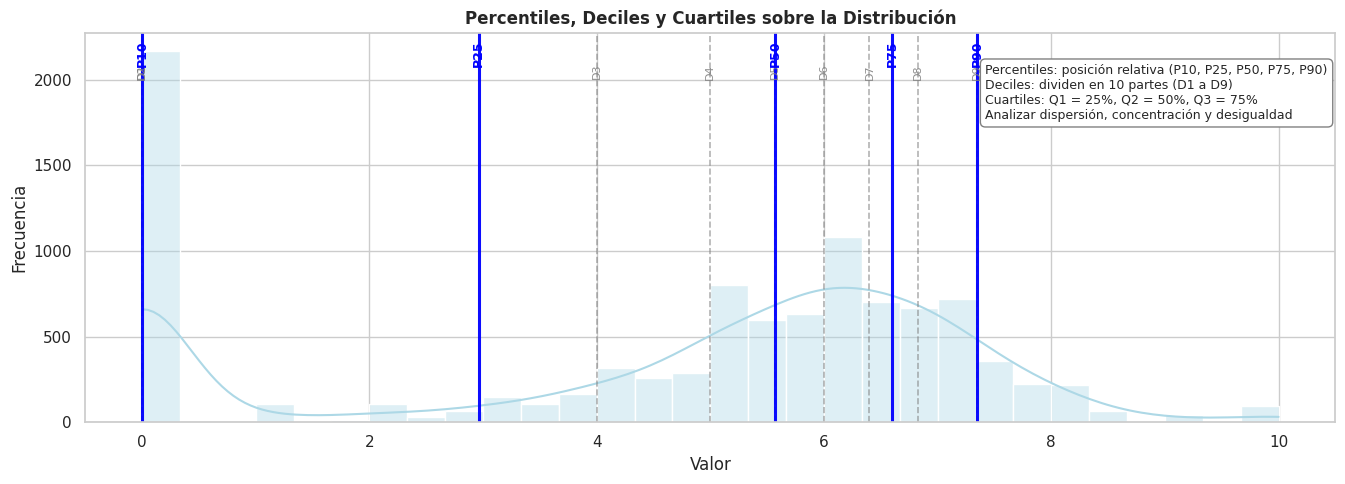

In [ ]:
sns.set_theme(style="whitegrid")

# Muestra (tu data real)
x = df["vote_average"].dropna().to_numpy()

# Percentiles clave (los azules del ejemplo)
p_keys = np.array([10, 25, 50, 75, 90])
p_vals = np.percentile(x, p_keys)

# Deciles (D1..D9)
d_keys = np.arange(10, 100, 10)   # 10..90
d_vals = np.percentile(x, d_keys)

# Cuartiles (para texto explicativo)
q1, q2, q3 = np.percentile(x, [25, 50, 75])

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(14, 5))

sns.histplot(x, bins=30, kde=True, color="lightblue", edgecolor="white", alpha=0.4, ax=ax)

ax.set_title("Percentiles, Deciles y Cuartiles sobre la Distribución", fontweight="bold")
ax.set_xlabel("Valor")
ax.set_ylabel("Frecuencia")

# Deciles (gris punteado, con etiquetas D1..D9)
for i, (dk, dv) in enumerate(zip(d_keys, d_vals), start=1):
    ax.axvline(dv, color="gray", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.text(dv, ax.get_ylim()[1]*0.92, f"D{i}", rotation=90,
            color="gray", ha="center", va="top", fontsize=8, alpha=0.9)

# Percentiles clave (azules fuertes con texto P10..P90)
for pk, pv in zip(p_keys, p_vals):
    ax.axvline(pv, color="blue", linewidth=2.2, alpha=0.95)
    ax.text(pv, ax.get_ylim()[1]*0.98, f"P{pk}", rotation=90,
            color="blue", ha="center", va="top", fontsize=9, fontweight="bold")

# Caja explicativa (derecha)
texto = (
    "Percentiles: posición relativa (P10, P25, P50, P75, P90)\n"
    "Deciles: dividen en 10 partes (D1 a D9)\n"
    "Cuartiles: Q1 = 25%, Q2 = 50%, Q3 = 75%\n"
    "Analizar dispersión, concentración y desigualdad"
)

ax.text(
    0.72, 0.92, texto,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray")
)

plt.tight_layout()
plt.show()

## Interpretaciones:

El percentil 10 (P10) es 0.000, lo que indica que el 10 % de los valores es igual o menor a 0, mostrando la presencia de valores muy bajos. El percentil 25 (P25) es 2.963, lo que significa que el 25 % de los datos se encuentra por debajo de este valor, mientras que la mediana o percentil 50 (P50) es 5.571. El percentil 75 (P75) es 6.600 y el percentil 90 (P90) es 7.349, lo que indica que la gran mayoría de los datos se concentra por debajo de estos valores. En conjunto, estos percentiles permiten entender la distribución progresiva y la concentración de las observaciones.



## **Parte 2: Análisis Bivariado**

### **Ejercicio 5: Análisis de correlación**

Pearson r = 0.7039 (p=1.42e-05)
Spearman ρ = 0.6449 (p=0.000119)


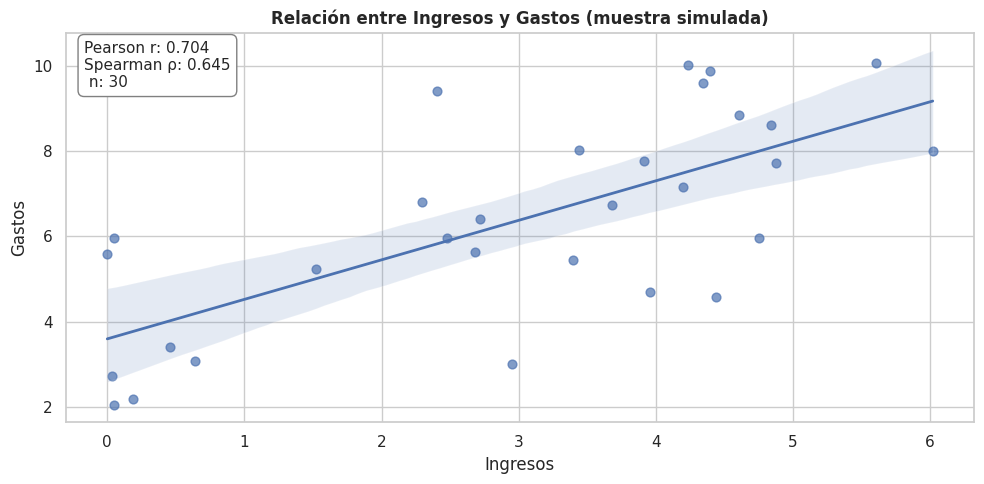

In [ ]:
sns.set_theme(style="whitegrid")

# Base (últimos 6 dígitos)
BASE = 631221
np.random.seed(BASE)

n = 30
sigma = 2

# Medias teóricas derivadas de la cédula (2..11)
mu_ingresos = (BASE % 10) + 2
mu_gastos   = ((BASE // 10) % 10) + 2  # usa el penúltimo dígito

# Variables normales
ingresos = np.random.normal(loc=mu_ingresos, scale=sigma, size=n)

# Gastos correlacionados con ingresos (para que la relación exista)
gastos = 0.7 * ingresos + np.random.normal(loc=mu_gastos, scale=sigma, size=n)

# no permitir negativos
ingresos = np.where(ingresos < 0, 0, ingresos)
gastos = np.where(gastos < 0, 0, gastos)

# Correlaciones
pearson_r, pearson_p = pearsonr(ingresos, gastos)
spearman_r, spearman_p = spearmanr(ingresos, gastos)

print(f"Pearson r = {pearson_r:.4f} (p={pearson_p:.3g})")
print(f"Spearman ρ = {spearman_r:.4f} (p={spearman_p:.3g})")

# Gráfica tipo ejemplo
plt.figure(figsize=(10,5))
ax = plt.gca()

sns.regplot(x=ingresos, y=gastos, scatter_kws={"alpha":0.7, "s":40}, line_kws={"linewidth":2}, ax=ax)

ax.set_title("Relación entre Ingresos y Gastos (muestra simulada)", fontweight="bold")
ax.set_xlabel("Ingresos")
ax.set_ylabel("Gastos")

ax.text(
    0.02, 0.98,
    f"Pearson r: {pearson_r:.3f}\nSpearman ρ: {spearman_r:.3f}\n n: {n}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray")
)

plt.tight_layout()
plt.show()

## Interpretaciones:

Tenemos en el eje x los ingresos y en el eje Y los gastos, es una prueba simulada, cabe aclarar esto, porque en las graficas del univariado, no simulamos, sino que tomamos feature del dataset

en la grafica se observa una tendencia creciente, esto nos dice que a medida de que crecen los ingresos, tambien crecen los gastos y a pesar de que no es una relacion perfecta, los coeficientes terminan de confirmar la hipotesis, el de Pearson 0.704, y nos dice que no hay una correlacion positiva perfecta, pero que hay, es moderada y el de Spearman que es 0.645, me dice algo muy similar, que no tiene una correlacion positiva perfecta pero que existe una relacion monotona creciente


### **Ejercicio 6: Chi-Cuadrado**

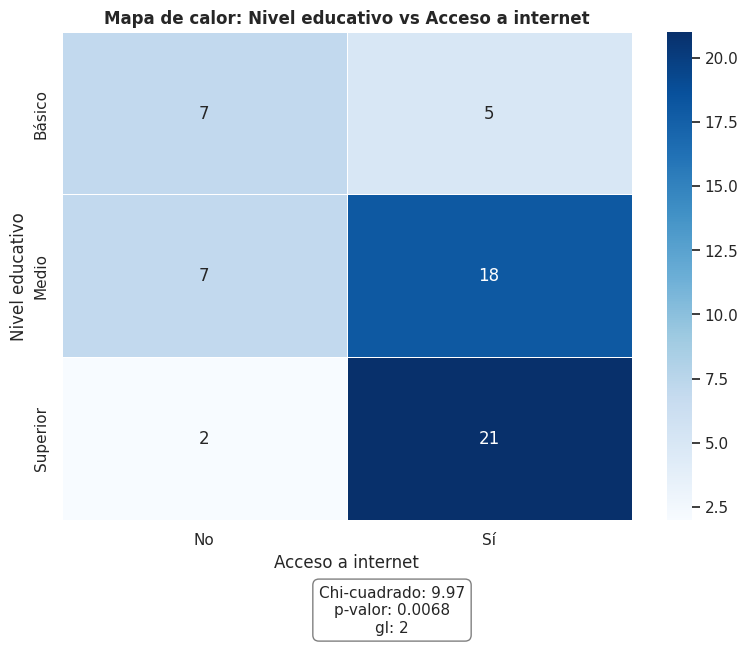

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")

# Semilla reproducible
BASE = 631221
np.random.seed(BASE)

# Tamaño de muestra
n = 60

# Categorías
niveles = ["Básico", "Medio", "Superior"]
internet = ["Sí", "No"]

# Simulación
nivel_educativo = np.random.choice(niveles, size=n, p=[0.3, 0.4, 0.3])

acceso_internet = []
for nivel in nivel_educativo:
    if nivel == "Básico":
        acceso_internet.append(np.random.choice(internet, p=[0.45, 0.55]))
    elif nivel == "Medio":
        acceso_internet.append(np.random.choice(internet, p=[0.70, 0.30]))
    else:
        acceso_internet.append(np.random.choice(internet, p=[0.90, 0.10]))

# DataFrame
df_chi = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

# Tabla de contingencia
tabla = pd.crosstab(df_chi["Nivel educativo"], df_chi["Acceso a internet"])

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)

# Gráfico
plt.figure(figsize=(8, 6.5))
ax = sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", cbar=True, linewidths=0.5)

plt.title("Mapa de calor: Nivel educativo vs Acceso a internet", fontweight="bold")
plt.xlabel("Acceso a internet")
plt.ylabel("Nivel educativo")

texto = (
    f"Chi-cuadrado: {chi2:.2f}\n"
    f"p-valor: {p:.4f}\n"
    f"gl: {dof}"
)

plt.figtext(
    0.5, 0.01, texto,
    ha="center",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray")
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# Interpretaciones:

Al igual que el anterior este es una prueba simulada, en el mapa de calor podemos observar los diferentes niveles educativos y cuantas personas tienen y no tienen acceso a internet en cada uno de ellos, podemos ver como en el nivel basico, es muy igualado 7 no tienen y 5 si tienen, en el nivel medio que es donde mas estudiantes se encuentran, la cifra cambia y 18 personas si tinen y 7 no tienen y en el nivel superior nos encontramos que casi todos los de ese nivel tienen internet coon un total de 21 personas y solo 2 que no tienen, a pesar de que esto no es analisis y se puede ver de manera clara en la tabla, creo pertinente nombrarlo para pasar al analisis

el p-valor es menor a 0.05 la hipotesis nula se rechaza por lo que me queda que hay una asociación entre las dos variables, y lo podemos notar con lo anteriormente mencionado, entre mas alto el nivel educativo mas personas tienen acceso a internet y el Chi-cuadrado nos dice que existe una diferencia  entre las frecuencias observadas y las frecuencias esperadas bajo el supuesto de independencia


##Analisis multivariado



##Decisiones:
Analizando nuestro dataset nos damos cuenta de que no tenemos muchas caracteristicas con lo que realizar un analisis multivariado solido con PCA, por lo que decidimos hacer regresion lineal multiple (a pesar de que si puedo realizar PCA, sentimos que no aportara tanto, por lo anteriormente nombrado, no quiere decir que no lo podamos realizar ), nuestra variable dependiente sera vote_average y las predictoras: popularity, vote_count y release_year, que la tomaremos de la caracteristica fecha (nos toca cambiar la variable a tipo fecha y extraer el año)


In [5]:
X = df_reg[["popularity", "log_vote_count", "release_year"]]
y = df_reg["vote_average"]

X_const = sm.add_constant(X)
modelo = sm.OLS(y, X_const).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     2293.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:18:49   Log-Likelihood:                -21268.
No. Observations:                9852   AIC:                         4.254e+04
Df Residuals:                    9848   BIC:                         4.257e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.1272      1.719     -0.

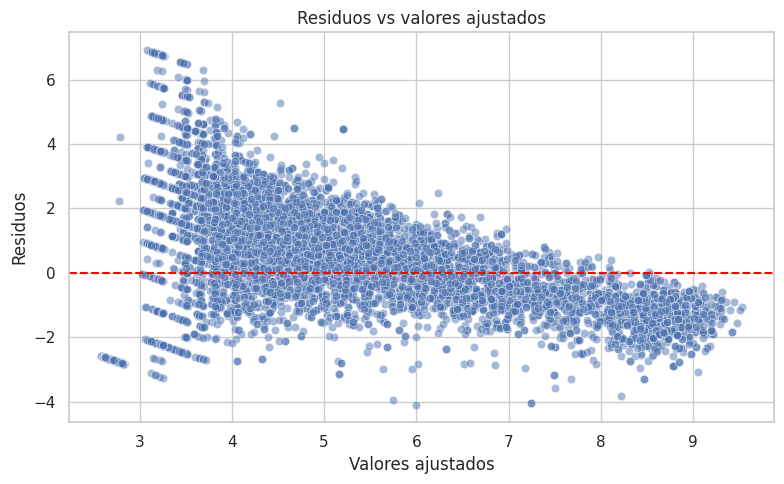

In [6]:
y_ajustado = modelo.fittedvalues
residuos = modelo.resid

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_ajustado, y=residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs valores ajustados")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.tight_layout()
plt.show()

##Analisis:

LO que esperamos en este grafico es que los puntos esten aleatoriamente y no generen ningun tipo de patron, sin embargo aqui podemos ver todo lo contrario, tenemos un patron ademas de que los puntos se distribuyen de una manera desigual, esto indica que la homocedasticidad no se cumple y el modelo lineal no representa completamente la relación entre las variables

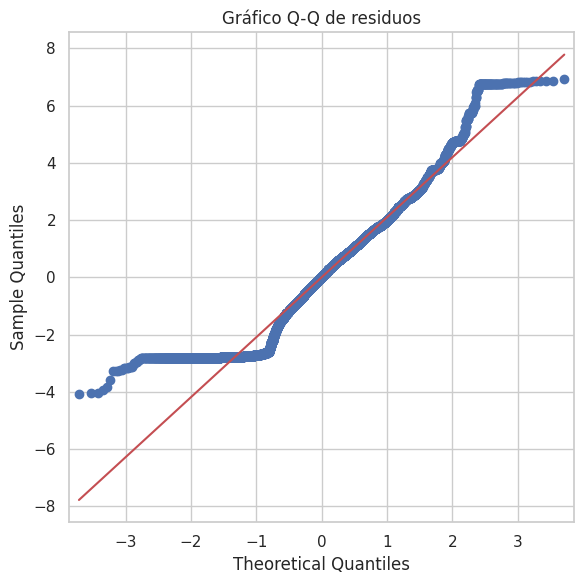

In [7]:
from statsmodels.graphics.gofplots import qqplot

plt.figure(figsize=(6,6))
qqplot(residuos, line="s", ax=plt.gca())
plt.title("Gráfico Q-Q de residuos")
plt.tight_layout()
plt.show()

##Analisis

podemos ver claramente como el grafico nos indica que no cumple normalidad, lo que nos dice que el modelo puede presentar desviaciones respecto a una distribucion normal en los errores


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif)

         Variable          VIF
0           const  6623.753776
1      popularity     1.018491
2  log_vote_count     1.054480
3    release_year     1.046543


## Analisis

Los valores son cercanos a 1, nos indica que no hay multicolinealidad


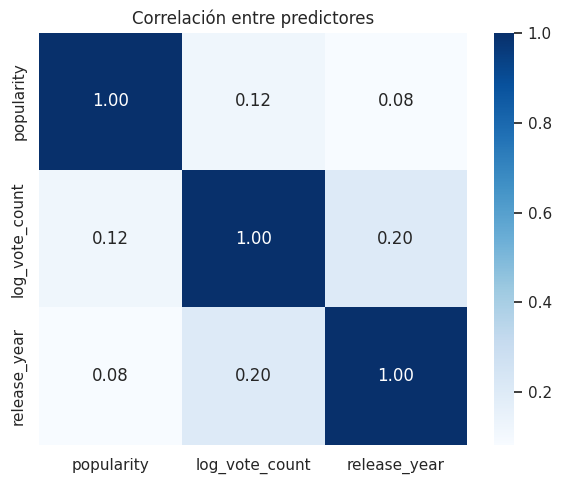

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(X.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlación entre predictores")
plt.tight_layout()
plt.show()

##Analisis

La matriz znos muestra asociaciones debiles entre las variables predictoras, no tienen una relacion fuerte entre si, esto nos confirma la ausencia de multicolinealidad que vimos en los valores de arriba